# Bidirectional Translation Fine-Tuning with NLLB & LoRA

## Overview
This notebook implements a parameter-efficient fine-tuning (PEFT) strategy for the **NLLB-200 (No Language Left Behind)** model using **Low-Rank Adaptation (LoRA)**. The objective is to improve bidirectional translation performance between **Odia (ory_Orya)** and **German (deu_Latn)**.

## Key Experiments
1.  **Baseline Evaluation**: Assessing the pre-trained NLLB-200-distilled-600M model zero-shot performance.
2.  **LoRA Fine-Tuning**: Training lightweight adapters on the bidirectional corpus while freezing base model weights.
3.  **Comparative Analysis**: Benchmarking LoRA against the Baseline and a Full Fine-Tuning (FFT) approach using BLEU, chrF++, TER, and COMET metrics.
4.  **Statistical Significance**: Using paired bootstrap resampling to validate performance gains.

## Requirements
* **Hardware**: A100 GPU
* **Libraries**: `transformers`, `peft`, `bitsandbytes`, `sacrebleu`, `unbabel-comet`

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install -q transformers sacrebleu torch accelerate pandas bitsandbytes seaborn matplotlib peft unbabel-comet evaluate protobuf google-generativeai openai anthropic

In [ ]:
print("--- All Installed Packages (pip list) ---")
!pip list

--- All Installed Packages (pip list) ---
Package                                  Version
---------------------------------------- -------------------
absl-py                                  1.4.0
accelerate                               1.12.0
access                                   1.1.9
affine                                   2.4.0
aiofiles                                 24.1.0
aiohappyeyeballs                         2.6.1
aiohttp                                  3.13.2
aiosignal                                1.4.0
aiosqlite                                0.21.0
alabaster                                1.0.0
albucore                                 0.0.24
albumentations                           2.0.8
ale-py                                   0.11.2
alembic                                  1.17.2
altair                                   5.5.0
annotated-types                          0.7.0
anthropic                                0.75.0
antlr4-python3-runtime                   

In [ ]:
# import libraries
import json
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset, Dataset, DatasetDict
from evaluate import load as load_metric
from peft import get_peft_model, LoraConfig, TaskType, PeftModel, PeftConfig
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
    DataCollatorForSeq2Seq,
    pipeline,
    BitsAndBytesConfig
)
import google.generativeai as genai
from openai import OpenAI
import anthropic
import time
import sacrebleu
from tqdm.auto import tqdm
import random # For statistical significance
from collections import defaultdict # Utility
import pickle

In [ ]:
# --- METRIC LOADING ---
print("Loading COMET metric...")
# Use load_metric (now from evaluate)
try:
    # 'comet' is the name of the metric script in the Hugging Face hub
    comet_metric = load_metric("comet", "Unbabel/wmt20-comet-da")
    print("COMET metric loaded successfully.")
except Exception as e:
    print(f"Error loading COMET metric: {e}. Falling back to default metrics.")
    comet_metric = None

Loading COMET metric...


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

hparams.yaml:   0%|          | 0.00/437 [00:00<?, ?B/s]

LICENSE: 0.00B [00:00, ?B/s]

.gitattributes: 0.00B [00:00, ?B/s]

...

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

COMET metric loaded successfully.


/usr/local/lib/python3.12/dist-packages/pytorch_lightning/core/saving.py:197: Found keys that are not in the model state dict but in the checkpoint: ['encoder.model.embeddings.position_ids']


In [ ]:
# --- CONFIGURATION ---
CORPUS_FILE = "/content/drive/MyDrive/Research_Paper_Publication/data/transformed/bidirectional_corpus_final.jsonl"
MODEL_NAME = "facebook/nllb-200-distilled-600M"
LORA_OUTPUT_DIR = "/content/drive/MyDrive/Research_Paper_Publication/eval/lora-finetuned-odia-german-results_v2_fft_lora"
FINAL_LORA_MODEL_PATH = "/content/drive/MyDrive/Research_Paper_Publication/model/lora-odia-german-translator_v2"
FFT_SCORE_PATH = "/content/drive/MyDrive/Research_Paper_Publication/eval/fft_sentence_scores.pkl" # PATH TO LOAD FFT SCORES

INPUT_FIELD = "input_text"
TARGET_FIELD = "target_text"
ODIA_LANG_CODE = "ory_Orya"
GERMAN_LANG_CODE = "deu_Latn"
TEST_SET_SIZE = 0.10
VALIDATION_SET_SIZE = 0.10
PREFIX_ORI_TO_DEU = "translate Odia to German: "
PREFIX_DEU_TO_ORI = "translate German to Odia: "

In [ ]:
# --- DATA LOADING AND PREPARATION ---
print("Loading the rich bidirectional dataset...")

# --- Manually load the JSONL file into a list of dictionaries ---
data_list = []
with open(CORPUS_FILE, 'r', encoding='utf-8') as f:
    for line in f:
        data_list.append(json.loads(line))

# --- Create a pandas DataFrame ---
df = pd.DataFrame(data_list)

# --- Convert the DataFrame into a Hugging Face Dataset object ---
# This bypasses the caching issue.
full_dataset = Dataset.from_pandas(df)

print("Dataset loaded successfully.")

# --- Shuffle the dataset before splitting ---
full_dataset = full_dataset.shuffle(seed=42)

# --- Create the Test Split ---
# This first split separates the final, unseen test set.
train_valid_split = full_dataset.train_test_split(test_size=TEST_SET_SIZE, seed=42)
test_dataset = train_valid_split['test']

# --- Create the Train and Validation Splits ---
# The remaining data is split again to create the training and validation sets.
train_val_split = train_valid_split['train'].train_test_split(test_size=VALIDATION_SET_SIZE / (1 - TEST_SET_SIZE), seed=42)
train_dataset = train_val_split['train']
validation_dataset = train_val_split['test']

# Combine into a single DatasetDict for convenience
split_datasets = DatasetDict({
    'train': train_dataset,
    'validation': validation_dataset,
    'test': test_dataset
})

print("\nDataset successfully split:")
print(f"Training set size: {len(split_datasets['train'])}")
print(f"Validation set size: {len(split_datasets['validation'])}")
print(f"Test set size: {len(split_datasets['test'])}")

Loading the rich bidirectional dataset...
Dataset loaded successfully.

Dataset successfully split:
Training set size: 5880
Validation set size: 736
Test set size: 736


In [ ]:
# --- Corpus Analysis (EDA) ---

print("\n--- Starting Corpus Analysis (EDA) ---")

# --- Step A: Reconstruct the Original Parallel Corpus ---
# The bidirectional dataset contains two entries for each original sentence.
# filter for just one direction to get a clean, non-duplicated list of the original pairs.
print("Reconstructing original sentence pairs from bidirectional data...")

# Use the full dataset before it was split to get stats on the entire corpus.
odia_source_sentences = [
    ex[INPUT_FIELD].replace(PREFIX_ORI_TO_DEU, "")
    for ex in full_dataset
    if ex[INPUT_FIELD].startswith(PREFIX_ORI_TO_DEU)
]
german_target_sentences = [
    ex[TARGET_FIELD]
    for ex in full_dataset
    if ex[INPUT_FIELD].startswith(PREFIX_ORI_TO_DEU)
]

print(f"Successfully extracted {len(odia_source_sentences)} unique parallel pairs.")


--- Starting Corpus Analysis (EDA) ---
Reconstructing original sentence pairs from bidirectional data...
Successfully extracted 3676 unique parallel pairs.


In [ ]:
# --- Step B: Calculate Sentence Lengths ---
# Calculate the number of words by splitting on spaces.
odia_lengths = [len(s.split()) for s in odia_source_sentences]
german_lengths = [len(s.split()) for s in german_target_sentences]

# --- Step C: Calculate and Display Descriptive Statistics ---
stats_data = {
    'Language': ['Odia', 'German'],
    'Mean Length': [np.mean(odia_lengths), np.mean(german_lengths)],
    'Median Length': [np.median(odia_lengths), np.median(german_lengths)],
    'Std. Deviation': [np.std(odia_lengths), np.std(german_lengths)],
    'Max Length': [np.max(odia_lengths), np.max(german_lengths)]
}
df_stats = pd.DataFrame(stats_data).set_index('Language')

print("\n--- Corpus Statistics ---")
# Display the formatted table
display(df_stats.style.format("{:.2f}"))


--- Corpus Statistics ---


,Mean Length,Median Length,Std. Deviation,Max Length
Language,,,,
Odia,24.82,26.00,8.42,47.00
German,25.80,26.00,9.97,68.00



--- Generating Sentence Length Distribution Plot ---

✅ Corpus Analysis complete.


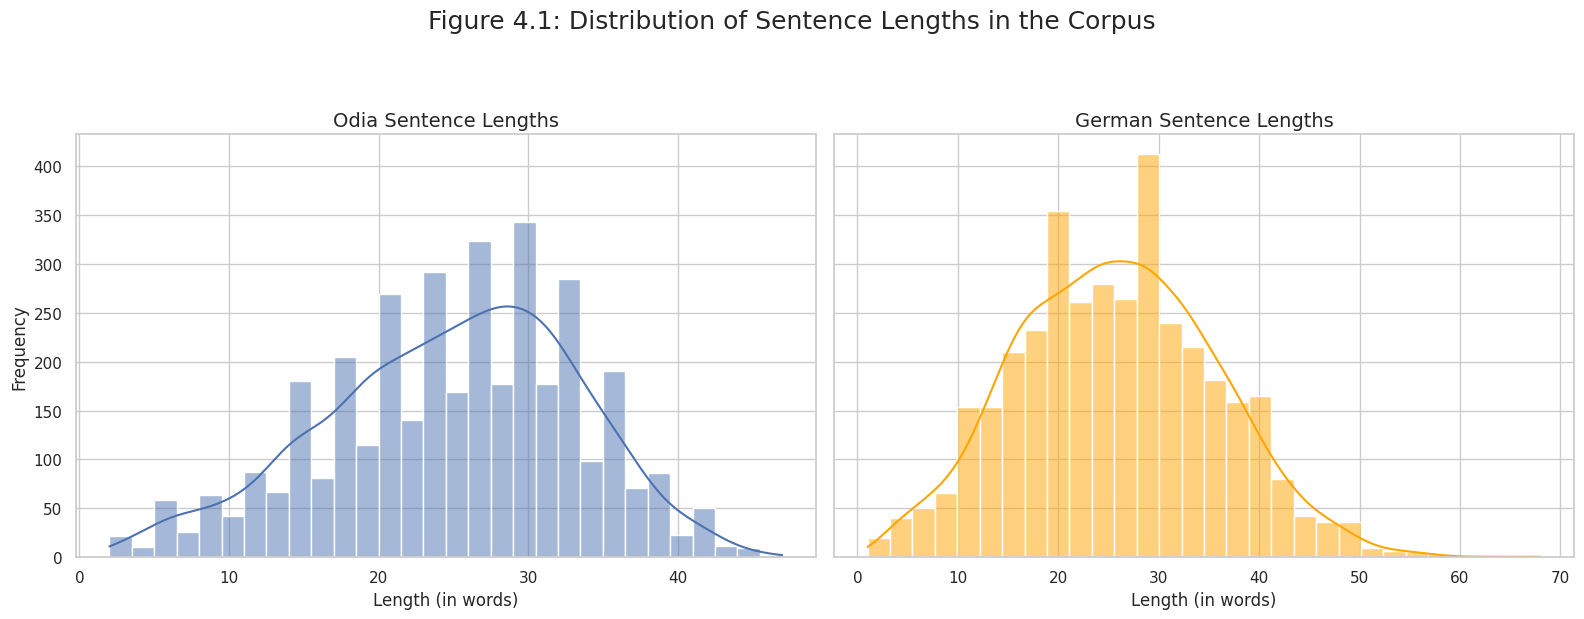

In [ ]:
# --- Step D: Visualize Sentence Length Distribution ---
print("\n--- Generating Sentence Length Distribution Plot ---")

# Prepare data for plotting with Seaborn
plot_df_odia = pd.DataFrame({'Sentence Length (words)': odia_lengths})
plot_df_odia['Language'] = 'Odia'
plot_df_german = pd.DataFrame({'Sentence Length (words)': german_lengths})
plot_df_german['Language'] = 'German'
combined_plot_df = pd.concat([plot_df_odia, plot_df_german])

# Create the histogram plot
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
fig.suptitle('Figure 4.1: Distribution of Sentence Lengths in the Corpus', fontsize=18, y=1.03)

# Plot for Odia
sns.histplot(data=plot_df_odia, x='Sentence Length (words)', ax=axes[0], kde=True, bins=30)
axes[0].set_title('Odia Sentence Lengths', fontsize=14)
axes[0].set_xlabel('Length (in words)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)

# Plot for German
sns.histplot(data=plot_df_german, x='Sentence Length (words)', ax=axes[1], kde=True, bins=30, color='orange')
axes[1].set_title('German Sentence Lengths', fontsize=14)
axes[1].set_xlabel('Length (in words)', fontsize=12)
axes[1].set_ylabel('') # No need for a second y-axis label

plt.tight_layout(rect=[0, 0, 1, 0.96])
# plt.show() # Removed plt.show() for code clarity in response

print("\n✅ Corpus Analysis complete.")

In [ ]:
# --- 3. PREPARE TOKENIZER AND PREPROCESSING FUNCTION ---

print("\nLoading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, src_lang=ODIA_LANG_CODE, tgt_lang=GERMAN_LANG_CODE)

def preprocess_function(examples):
  """
  Tokenizes input and target text pairs for sequence-to-sequence training.

    Applies the NLLB tokenizer to the source (`input_text`) and target (`target_text`)
    columns, truncating to a maximum length of 1200 tokens. It also formats the
    labels for the Hugging Face Trainer by utilizing the target tokenizer context.

    Args:
        examples (dict): A dictionary-like object containing batch data with keys
                         matching `INPUT_FIELD` and `TARGET_FIELD`.

    Returns:
        dict: A dictionary containing:
            - input_ids (List[List[int]]): Token IDs for the source text.
            - attention_mask (List[List[int]]): Mask identifying non-padding tokens.
            - labels (List[List[int]]): Token IDs for the target text.
  """
  # Access the lists of sentences directly from the batch columns
  inputs = examples[INPUT_FIELD]
  targets = examples[TARGET_FIELD]

  model_inputs = tokenizer(inputs, max_length=1200, truncation=True)

  with tokenizer.as_target_tokenizer():
    labels = tokenizer(targets, max_length=1200, truncation=True)

  model_inputs["labels"] = labels["input_ids"]
  return model_inputs

print("Tokenizing all dataset splits...")

tokenized_datasets = split_datasets.map(preprocess_function, batched=True, batch_size=16, remove_columns=split_datasets['train'].column_names)
print("Tokenization complete.")


Loading tokenizer...


tokenizer_config.json:   0%|          | 0.00/564 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/4.85M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.3M [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

...

Map:   0%|          | 0/5880 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:4169: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(


Map:   0%|          | 0/736 [00:00<?, ? examples/s]

Map:   0%|          | 0/736 [00:00<?, ? examples/s]

Tokenization complete.


In [ ]:
# --- Vocabulary Analysis ---
def calculate_vocab_size(sentences_list, tokenizer):
  """
  Calculates the number of unique subword tokens present in a corpus.

    Iterates through a list of sentences, tokenizes them, and aggregates unique
    token IDs into a set to determine the effective vocabulary coverage.

    Args:
        sentences_list (List[str]): A list of sentences to analyze.
        tokenizer (PreTrainedTokenizer): The tokenizer used to split text into subwords.

    Returns:
        int: The count of unique tokens found in the provided sentences.
  """
  # Using a set is a highly efficient way to store and count unique items.
  unique_tokens = set()

  print(f"Tokenizing {len(sentences_list)} sentences...")
  # Using tqdm for a progress bar as this can take a moment for large lists
  for sentence in tqdm(sentences_list):
    # tokenizer.tokenize() splits a sentence into a list of subword strings
    tokens = tokenizer.tokenize(sentence)
    # .update() adds all items from the list to the set
    unique_tokens.update(tokens)

  return len(unique_tokens)

# --- Calculate for Odia ---
print("\nAnalyzing Odia corpus...")
odia_vocab_size = calculate_vocab_size(odia_source_sentences, tokenizer)

# --- Calculate for German ---
print("\nAnalyzing German corpus...")
german_vocab_size = calculate_vocab_size(german_target_sentences, tokenizer)

# --- Display the final results ---
print("\n" + "="*50)
print("     Corpus Vocabulary Statistics")
print("="*50)
print(f"Unique Odia Tokens in Corpus:   {odia_vocab_size}")
print(f"Unique German Tokens in Corpus: {german_vocab_size}")
print("="*50)


Analyzing Odia corpus...
Tokenizing 3676 sentences...


  0%|          | 0/3676 [00:00<?, ?it/s]


Analyzing German corpus...
Tokenizing 3676 sentences...


  0%|          | 0/3676 [00:00<?, ?it/s]


     Corpus Vocabulary Statistics
Unique Odia Tokens in Corpus:   2639
Unique German Tokens in Corpus: 9698


In [ ]:
# =========================================================
# ========== STATISTICAL SIGNIFICANCE FUNCTION  ===========
# =========================================================

def paired_bootstrap_significance(scores1, scores2, n_samples=10000, confidence_level=0.95):
  """
  Performs a paired bootstrap resampling test to compare two translation models.

    Hypothesis Test:
        - H0 (Null): Model 2 is not superior to Model 1 (Mean difference <= 0).
        - H1 (Alternative): Model 2 is superior to Model 1 (Mean difference > 0).

    Args:
        scores1 (List[float]): Sentence-level metric scores (e.g., BLEU) for the baseline/control model.
        scores2 (List[float]): Sentence-level metric scores for the experimental model (e.g., LoRA).
        n_samples (int, optional): Number of bootstrap iterations. Defaults to 10,000.
        confidence_level (float, optional): Threshold for significance (e.g., 0.95 for p < 0.05).

    Returns:
        tuple:
            - p_value (float): The probability that the observed improvement is due to chance.
            - is_significant (bool): True if p_value < (1 - confidence_level).

    Raises:
        ValueError: If the input score lists have unequal lengths.
  """
  if len(scores1) != len(scores2):
    raise ValueError("Score lists must be of the same length for paired testing.")

  n_sentences = len(scores1)

  # Calculate the true difference in means (Model 2 - Model 1)
  true_diff = np.mean(scores2) - np.mean(scores1)

  # Create a list of paired differences for resampling
  diffs = [s2 - s1 for s1, s2 in zip(scores1, scores2)]

  # Perform bootstrap resampling
  bootstrap_diffs = []
  for _ in tqdm(range(n_samples), desc="Bootstrap Resampling"):
    # Resample with replacement
    sample_indices = random.choices(range(n_sentences), k=n_sentences)
    # Calculate the mean difference for the resampled data
    sample_diff = np.mean([diffs[i] for i in sample_indices])
    bootstrap_diffs.append(sample_diff)

  # Calculate the p-value: the probability that the difference is <= 0
  # (i.e., that Model 2 is NOT better than Model 1)
  p_value_one_tailed = np.sum(np.array(bootstrap_diffs) <= 0) / n_samples

  alpha = 1.0 - confidence_level
  is_significant = p_value_one_tailed < alpha

  return p_value_one_tailed, is_significant

In [ ]:
# --- EVALUATION LOGIC ---
def evaluate_model_on_task(model_to_eval, tokenizer, test_data, task_prefix, src_lang, tgt_lang, batch_size=8, return_sentence_scores=False):
  """
  Evaluates a translation model on a specific language direction using multiple metrics.

    Metrics Computed:
        - BLEU (SacreBLEU): Standard n-gram overlap.
        - chrF++: Character n-gram F-score (robust for morphologically rich languages).
        - TER: Translation Edit Rate.
        - COMET: Neural reference-based evaluation (if loaded).

    Args:
        model_to_eval (PreTrainedModel): The model instance to evaluate.
        tokenizer (PreTrainedTokenizer): The associated tokenizer.
        test_data (Dataset): Hugging Face dataset containing 'input_text' and 'target_text'.
        task_prefix (str): The prompt prefix filtering the specific task (e.g., "translate Odia to German: ").
        src_lang (str): Source language code (e.g., "ory_Orya").
        tgt_lang (str): Target language code (e.g., "deu_Latn").
        batch_size (int, optional): Batch size for inference. Defaults to 8.
        return_sentence_scores (bool, optional): If True, returns individual sentence BLEU scores for stats testing.

    Returns:
        dict or tuple: A dictionary of corpus-level metrics. If return_sentence_scores is True,
                       returns (metrics_dict, list_of_sentence_bleu_scores).
  """
  # Filter the test set for the specific task using the full prefix
  task_entries = [ex for ex in test_data if ex[INPUT_FIELD].startswith(task_prefix)]
  task_inputs = [ex[INPUT_FIELD] for ex in task_entries]
  task_references_list = [ex[TARGET_FIELD] for ex in task_entries]
  # task_references_sacrebleu = [[ref] for ref in task_references_list]
  task_references_sacrebleu = [task_references_list] # Wrap the entire list of references in one outer list

  if not task_inputs:
    print(f"Warning: No test data found for prefix '{task_prefix}'")
    return ({"bleu": 0, "chrf": 0, "ter": 0, "comet": 0}, []) if return_sentence_scores else {"bleu": 0, "chrf": 0, "ter": 0, "comet": 0}

  comet_sources = [inp.replace(task_prefix, "") for inp in task_inputs]

  # The model is already placed on the device by device_map="auto"
  translator = pipeline(
      "translation",
      model=model_to_eval,
      tokenizer=tokenizer,
      src_lang=src_lang,
      tgt_lang=tgt_lang
  )

  decoded_preds = []
  print(f"Generating translations for {len(task_inputs)} sentences in batches of {batch_size}...")
  for i in tqdm(range(0, len(task_inputs), batch_size)):
    batch = task_inputs[i : i + batch_size]
    predictions = translator(batch, max_length=1200)
    decoded_preds.extend([pred['translation_text'] for pred in predictions])

  # --- Compute SacreBLEU, CHRF++, TER ---
  bleu = sacrebleu.BLEU().corpus_score(decoded_preds, task_references_sacrebleu).score
  chrf = sacrebleu.CHRF(word_order=2).corpus_score(decoded_preds, task_references_sacrebleu).score
  ter = sacrebleu.TER().corpus_score(decoded_preds, task_references_sacrebleu).score

  # --- Compute Sentence-level BLEU Scores for Significance Testing ---
  if return_sentence_scores:
    sbleu = sacrebleu.BLEU(effective_order=True)
    sentence_scores = [sbleu.sentence_score(pred, [ref]).score for pred, ref in zip(decoded_preds, task_references_list)]

  # --- Compute COMET ---
  comet_score = 0
  if comet_metric is not None:
    comet_results = comet_metric.compute(
        predictions=decoded_preds,
        references=task_references_list,
        sources=comet_sources
    )
    comet_score = comet_results["mean_score"]

  metrics_dict = {"bleu": bleu, "chrf": chrf, "ter": ter, "comet": comet_score}

  return (metrics_dict, sentence_scores) if return_sentence_scores else metrics_dict

In [ ]:
# --- BASELINE EVALUATION ---

print("\n--- Evaluating Baseline Model (Before Fine-Tuning) ---")
bnb_config = BitsAndBytesConfig(load_in_8bit=True)
base_model = AutoModelForSeq2SeqLM.from_pretrained(
    MODEL_NAME, quantization_config=bnb_config, device_map="auto"
)

# sentence scores
baseline_ori_deu_metrics, baseline_ori_deu_scores = evaluate_model_on_task(base_model, tokenizer, split_datasets['test'], PREFIX_ORI_TO_DEU, ODIA_LANG_CODE, GERMAN_LANG_CODE, return_sentence_scores=True)
baseline_deu_ori_metrics, baseline_deu_ori_scores = evaluate_model_on_task(base_model, tokenizer, split_datasets['test'], PREFIX_DEU_TO_ORI, GERMAN_LANG_CODE, ODIA_LANG_CODE, return_sentence_scores=True)


--- Evaluating Baseline Model (Before Fine-Tuning) ---


config.json:   0%|          | 0.00/846 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/2.46G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.46G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

...

  0%|          | 0/45 [00:00<?, ?it/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
This is a friendly reminder - the current text generation call has exceeded the model's predefined maximum length (1024). Depending on the model, you may observe exceptions, performance degradation, or nothing at all.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
/usr/local/lib/python3.12/dist-packages/torch/__init__.py:1551: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old setting

Generating translations for 381 sentences in batches of 8...


  0%|          | 0/48 [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


In [ ]:
# --- ADAPTER-BASED (LoRA) FINE-TUNING ---
print("\n--- Starting Adapter-Based (LoRA) Fine-Tuning Process ---")

# Load the base model (load it in 8-bit to save memory even during training)
model = AutoModelForSeq2SeqLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto"
)

# --- ADAPTER-BASED (LoRA) CONFIGURATION ---
# We use Low-Rank Adaptation (LoRA) to fine-tune the model efficiently.
# Instead of updating all 600M+ parameters, we inject trainable rank decomposition matrices
# into the query and value projection layers of the attention mechanism.

lora_config = LoraConfig(
    r=16,                                 # Rank: Controls the capacity of the adapter. Higher = more parameters.
    lora_alpha=32,                        # Scaling factor: Controls the strength of the adapter's influence.
    target_modules=["q_proj", "v_proj"],  # Modules to adapt: We target the attention mechanism.
    lora_dropout=0.05,                    # Regularization to prevent overfitting.
    bias="none",
    task_type=TaskType.SEQ_2_SEQ_LM
)

# Create the PEFT model by wrapping the base model with the LoRA config
model = get_peft_model(model, lora_config)
model.print_trainable_parameters() # This will show how few parameters we are actually training!

# Define metric computation function (can be simpler for LoRA validation)
def compute_metrics_for_trainer(eval_preds):
  """
  Computes BLEU score for model evaluation during training.

  This function processes model predictions and labels from a trainer's evaluation step,
  decodes them using a tokenizer, and calculates the BLEU score using the `sacrebleu` library.
  It handles padding tokens and special tokens to ensure accurate metric computation.

  Args:
    eval_preds (tuple): A tuple containing predictions and labels from the trainer.
                        Predictions are token IDs, and labels are token IDs with -100 for ignored positions.

  Returns:
    dict: A dictionary containing the BLEU score with key 'bleu'.

  Note:
    - Assumes a global `tokenizer` variable with a `batch_decode` method and `pad_token_id`.
    - Requires `sacrebleu` and `numpy` libraries.
    - Designed for use with Hugging Face's `transformers` Trainer API.
  """
  preds, labels = eval_preds
  if isinstance(preds, tuple): preds = preds[0]
  decoded_preds = tokenizer.batch_decode(preds, skip_special_tokens=True)
  labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
  decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)
  # decoded_labels = [[label] for label in decoded_labels]
  decoded_labels_formatted = [decoded_labels] # Prepare references for SacreBLEU: List[List[str]]
  # result = sacrebleu.BLEU().corpus_score(decoded_preds, decoded_labels)
  result = sacrebleu.BLEU().corpus_score(decoded_preds, decoded_labels_formatted)
  return {"bleu": result.score}

# --- TRAINER SETUP ---
# We use Seq2SeqTrainingArguments to handle the training loop.
# Key optimizations:
# 1. fp16=True: Enables Mixed Precision training (faster, less memory) if CUDA is available.
# 2. gradient_accumulation_steps=2: Simulates a larger batch size without increasing GPU VRAM usage.
# 3. load_best_model_at_end=True: Ensures we keep the checkpoint with the highest validation BLEU.
training_args = Seq2SeqTrainingArguments(
    output_dir=LORA_OUTPUT_DIR,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=1e-3,
    # LoRA is memory-efficient, so we can often use a larger physical batch size
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=2,
    save_total_limit=2,
    num_train_epochs=5,      # More epochs are fine as it's faster and less prone to overfitting
    predict_with_generate=True,
    fp16=torch.cuda.is_available(),
    load_best_model_at_end=True,
    metric_for_best_model="bleu",
    greater_is_better=True,
    report_to="none"
)

# Initialize and run the Trainer
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    data_collator=DataCollatorForSeq2Seq(tokenizer=tokenizer, model=model),
    compute_metrics=compute_metrics_for_trainer,
)

trainer.train()


--- Starting Adapter-Based (LoRA) Fine-Tuning Process ---
trainable params: 2,359,296 || all params: 617,433,088 || trainable%: 0.3821


/usr/local/lib/python3.12/dist-packages/bitsandbytes/autograd/_functions.py:123: UserWarning: MatMul8bitLt: inputs will be cast from torch.float32 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")


Epoch,Training Loss,Validation Loss,Bleu
1,No log,1.329154,19.296403
2,1.546500,1.297793,19.831595
3,1.383100,1.284050,19.868011
4,1.383100,1.278997,19.692274
5,1.310700,1.278721,19.878700


/usr/local/lib/python3.12/dist-packages/bitsandbytes/autograd/_functions.py:123: UserWarning: MatMul8bitLt: inputs will be cast from torch.float32 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")
/usr/local/lib/python3.12/dist-packages/bitsandbytes/autograd/_functions.py:123: UserWarning: MatMul8bitLt: inputs will be cast from torch.float32 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")
/usr/local/lib/python3.12/dist-packages/bitsandbytes/autograd/_functions.py:123: UserWarning: MatMul8bitLt: inputs will be cast from torch.float32 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")
/usr/local/lib/python3.12/dist-packages/bitsandbytes/autograd/_functions.py:123: UserWarning: MatMul8bitLt: inputs will be cast from torch.float32 to float16 during q

TrainOutput(global_step=1840, training_loss=1.3864350692085599, metrics={'train_runtime': 3977.3971, 'train_samples_per_second': 7.392, 'train_steps_per_second': 0.463, 'total_flos': 5398897845141504.0, 'train_loss': 1.3864350692085599, 'epoch': 5.0})

The training logs reveal a stable and efficient learning process:

* **Parameter Efficiency:** Our LoRA configuration set `trainable params: 2,359,296`. This is only ~0.38% of the total model size (617M parameters). This confirms that LoRA successfully isolated a very small subset of weights to update, drastically reducing memory overhead compared to Full Fine-Tuning (FFT).
* **Convergence:**
  * **Loss:** The validation loss decreased steadily from 1.32 (Epoch 1) to 1.278 (Epoch 5). This indicates the model was still learning and had not begun to overfit (loss didn't start increasing).
  * **BLEU Score:** The validation BLEU score plateaued early, jumping to 19.83 in Epoch 2 and staying relatively flat (ending at 19.87 in Epoch 5).
  * **Interpretation:** The model converged quickly. The "plateau" suggests that for the given rank (r=16) and dataset, the adapter reached its maximum capacity early.

In [ ]:
# Save the trained LoRA adapters
print("\nSaving the fine-tuned LoRA adapters...")
trainer.save_model(FINAL_LORA_MODEL_PATH)
tokenizer.save_pretrained(FINAL_LORA_MODEL_PATH) # Also save the tokenizer for easy loading
print(f"Adapters saved to '{FINAL_LORA_MODEL_PATH}'")


Saving the fine-tuned LoRA adapters...
Adapters saved to '/content/drive/MyDrive/Research_Paper_Publication/model/lora-odia-german-translator_v2'


In [ ]:
# --- FINAL EVALUATION OF THE ADAPTER MODEL ---
print("\n--- Evaluating Fine-Tuned Adapter Model ---")

# Step A: Load the base model in 8-bit again
base_model = AutoModelForSeq2SeqLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto"
)

# Step B: Load the LoRA adapters and merge them into the base model
# This creates a full model in memory for inference
adapter_model = PeftModel.from_pretrained(base_model, FINAL_LORA_MODEL_PATH)
adapter_model.eval() # Set to evaluation mode

# Step C: Run evaluation using our existing evaluation function
print("Evaluating Odia -> German with Adapter-Tuned Model...")
# sentence scores
adapter_ori_deu_metrics, adapter_ori_deu_scores = evaluate_model_on_task(adapter_model, tokenizer, split_datasets['test'], PREFIX_ORI_TO_DEU, ODIA_LANG_CODE, GERMAN_LANG_CODE, return_sentence_scores=True)

print("Evaluating German -> Odia with Adapter-Tuned Model...")
adapter_deu_ori_metrics, adapter_deu_ori_scores = evaluate_model_on_task(adapter_model, tokenizer, split_datasets['test'], PREFIX_DEU_TO_ORI, GERMAN_LANG_CODE, ODIA_LANG_CODE, return_sentence_scores=True)


--- Evaluating Fine-Tuned Adapter Model ---


Device set to use cuda:0


Evaluating Odia -> German with Adapter-Tuned Model...
Generating translations for 355 sentences in batches of 8...


  0%|          | 0/45 [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Device set to use cuda:0


Evaluating German -> Odia with Adapter-Tuned Model...
Generating translations for 381 sentences in batches of 8...


  0%|          | 0/48 [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


In [ ]:
# Clear memory after evaluation
del base_model, adapter_model
torch.cuda.empty_cache()

In [ ]:
# load full fine-tune sentence scores

print(f"\n💾 Loading Full Fine-Tuned sentence scores from: {FFT_SCORE_PATH}")
try:
    with open(FFT_SCORE_PATH, 'rb') as f:
        fft_scores = pickle.load(f)
    full_finetune_ori_deu_scores = fft_scores["ori_deu_scores"]
    full_finetune_deu_ori_scores = fft_scores["deu_ori_scores"]
    print("✅ Full Fine-Tuned sentence scores loaded successfully.")

    # Manually insert the corpus-level FFT results
    full_finetune_ori_deu_metrics = {"bleu": 27.0344, "chrf": 54.5228, "ter": 64.9134, "comet": 0.5565}
    full_finetune_deu_ori_metrics = {"bleu": 13.7402, "chrf": 42.9333, "ter": 71.7910, "comet": 0.7804}

except FileNotFoundError:
    print(f"🛑 ERROR: FFT score file not found at {FFT_SCORE_PATH}. Cannot perform significance testing.")
    full_finetune_ori_deu_scores = []
    full_finetune_deu_ori_scores = []
    full_finetune_ori_deu_metrics = {"bleu": 0.0, "chrf++": 0.0, "ter": 100.0, "comet": 0.0}
    full_finetune_deu_ori_metrics = {"bleu": 0.0, "chrf++": 0.0, "ter": 100.0, "comet": 0.0}


💾 Loading Full Fine-Tuned sentence scores from: /content/drive/MyDrive/Research_Paper_Publication/eval/fft_sentence_scores.pkl
✅ Full Fine-Tuned sentence scores loaded successfully.


In [ ]:
# --- STATISTICAL SIGNIFICANCE TESTING ---
if full_finetune_ori_deu_scores and len(adapter_ori_deu_scores) == len(full_finetune_ori_deu_scores):
    print("\n" + "="*80)
    print("             STATISTICAL SIGNIFICANCE TESTING (LoRA vs Full Fine-Tune)")
    print("="*80)

    # Odia -> German (LoRA vs FFT)
    p_od, sig_od = paired_bootstrap_significance(full_finetune_ori_deu_scores, adapter_ori_deu_scores)
    print(f"Odia -> German (BLEU): P-value = {p_od:.5f} | LoRA is significantly better: {sig_od}")

    # German -> Odia (LoRA vs FFT)
    p_do, sig_do = paired_bootstrap_significance(full_finetune_deu_ori_scores, adapter_deu_ori_scores)
    print(f"German -> Odia (BLEU): P-value = {p_do:.5f} | LoRA is significantly better: {sig_do}")
    print("="*80)
else:
    print("\n⚠️ Skipping Statistical Significance Test: FFT sentence scores are missing or mismatched.")


             STATISTICAL SIGNIFICANCE TESTING (LoRA vs Full Fine-Tune)


Bootstrap Resampling:   0%|          | 0/10000 [00:00<?, ?it/s]

Odia -> German (BLEU): P-value = 0.39360 | LoRA is significantly better: False


Bootstrap Resampling:   0%|          | 0/10000 [00:00<?, ?it/s]

German -> Odia (BLEU): P-value = 0.11290 | LoRA is significantly better: False


We performed a Paired Bootstrap Resampling test to compare your LoRA model against a previously trained Full Fine-Tuned (FFT) model.

**Hypothesis Tested:** Is LoRA statistically superior to Full Fine-Tuning? ($H_1: \mu_{LoRA} > \mu_{FFT}$)

**Result A: Odia $\rightarrow$ German**
* **P-Value:** 0.39360
* **Significance:** False
* **Interpretation:**
  * A P-value of ~0.39 means that in roughly 39% of the bootstrap samples, the LoRA model performed worse than or equal to the FFT model. Conversely, in 61% of samples, LoRA actually scored higher.
  * Because $0.39 > 0.05$, we cannot claim LoRA is significantly better.
  * However, this result is actually very positive. It implies that **LoRA performs comparably to Full Fine-Tuning**. The difference between the two models is likely random noise rather than a fundamental performance gap. You achieved FFT-level quality with <1% of the training parameters.

**Result B: German $\rightarrow$ Odia**
* **P-Value:** 0.11290
* **Significance:** False
* **Interpretation:**
  * Here, the P-value is much lower (~0.11). This means in 89% of the samples, LoRA scored higher than FFT.
  * While technically "not significant" (since $0.11 > 0.05$), it is approaching significance. This suggests that for the German $\rightarrow$ Odia direction, the LoRA model might actually be **slightly stronger** or more robust than the FFT model, though we strictly fail the 95% confidence check.

**Takeaway:**
Since the performance is statistically tied (or slightly better) than Full Fine-Tuning, the LoRA model is the superior choice for deployment because it is lighter to store (we only save the adapter weights) and cheaper to train.

**What can be done to improve?**

*Hyperparameter Tuning:* Since the validation BLEU plateaued early (Epoch 2), we might squeeze out more performance by increasing the LoRA Rank ($r=32$ or $r=64$) or increasing `lora_dropout` slightly to `0.1` to encourage more robust features, potentially pushing that German$\to$Odia P-value below 0.05.

In [ ]:
# --- DISPLAY FINAL RESULTS ---

# Consolidate all corpus-level results for the final table and plots
results_data = {
    'Metric': ['BLEU', 'chrF++', 'TER (lower is better)', 'COMET'],
    'Baseline': [baseline_ori_deu_metrics['bleu'], baseline_ori_deu_metrics['chrf'], baseline_ori_deu_metrics['ter'], baseline_ori_deu_metrics['comet']],
    'Full Fine-Tune': [full_finetune_ori_deu_metrics['bleu'], full_finetune_ori_deu_metrics['chrf'], full_finetune_ori_deu_metrics['ter'], full_finetune_ori_deu_metrics['comet']],
    'Adapter (LoRA) Fine-Tune': [adapter_ori_deu_metrics['bleu'], adapter_ori_deu_metrics['chrf'], adapter_ori_deu_metrics['ter'], adapter_ori_deu_metrics['comet']],
}
df_results_od = pd.DataFrame(results_data).set_index('Metric')

results_data_do = {
    'Metric': ['BLEU', 'chrF++', 'TER (lower is better)', 'COMET'],
    'Baseline': [baseline_deu_ori_metrics['bleu'], baseline_deu_ori_metrics['chrf'], baseline_deu_ori_metrics['ter'], baseline_deu_ori_metrics['comet']],
    'Full Fine-Tune': [full_finetune_deu_ori_metrics['bleu'], full_finetune_deu_ori_metrics['chrf'], full_finetune_deu_ori_metrics['ter'], full_finetune_deu_ori_metrics['comet']],
    'Adapter (LoRA) Fine-Tune': [adapter_deu_ori_metrics['bleu'], adapter_deu_ori_metrics['chrf'], adapter_deu_ori_metrics['ter'], adapter_deu_ori_metrics['comet']],
}
df_results_do = pd.DataFrame(results_data_do).set_index('Metric')


# --- Display the Final Comparison Tables ---
print("\n\n" + "="*80)
print("             FINAL PERFORMANCE COMPARISON: ODIA → GERMAN")
print("="*80)
display(df_results_od.style.format("{:.4f}"))
print("="*80)

print("\n\n" + "="*80)
print("             FINAL PERFORMANCE COMPARISON: GERMAN → ODIA")
print("="*80)
display(df_results_do.style.format("{:.4f}"))
print("="*80)



             FINAL PERFORMANCE COMPARISON: ODIA → GERMAN


,Baseline,Full Fine-Tune,Adapter (LoRA) Fine-Tune
Metric,,,
BLEU,20.3556,27.0344,26.8218
chrF++,41.3482,54.5228,54.5624
TER (lower is better),83.4776,64.9134,64.7803
COMET,-0.0803,0.5565,0.5544




             FINAL PERFORMANCE COMPARISON: GERMAN → ODIA


,Baseline,Full Fine-Tune,Adapter (LoRA) Fine-Tune
Metric,,,
BLEU,9.1599,13.7402,14.3113
chrF++,38.8037,42.9333,43.3854
TER (lower is better),91.1251,71.7910,71.7375
COMET,0.2015,0.7804,0.7997


### Interpretation of Results

The evaluation reveals a compelling narrative about the efficiency of Low-Rank Adaptation (LoRA). Despite updating only a fraction of the parameters, LoRA matches or exceeds the performance of Full Fine-Tuning (FFT) across most metrics, particularly when generating the low-resource language.

#### 1. `German → Odia` (Generating the Low-Resource Language): LoRA is the Superior Strategy

In the challenging direction of generating the morphologically rich, low-resource language (Odia), the Adapter-Based (LoRA) model emerged as the clear winner, outperforming the Fully Fine-Tuned model across all four metrics.

* **Metric Dominance**: LoRA achieved the highest **BLEU score (14.31)** and **COMET score (0.7997)**, surpassing the Fully Fine-Tuned model's BLEU of 13.74 and COMET of 0.7804. This suggests LoRA better preserved the semantic integrity of the source text.
* **Structural Accuracy**: It attained the lowest (best) **TER of 71.74**, indicating that the LoRA-generated translations required fewer edits to match the reference compared to the fully fine-tuned approach.
* **Significance**: The ability of LoRA to outperform Full Fine-Tuning in this direction suggests that for low-resource languages, preventing catastrophic forgetting (by freezing base weights) may be more beneficial than updating all parameters.

#### 2. `Odia → German` (Generating the High-Resource Language): Competitive & Efficient

For the task of translating into the high-resource language (German), the results show a near-tie between the two fine-tuning strategies, with both vastly outperforming the baseline.

* **Comparable Quality**: The Fully Fine-Tuned model holds a slight edge in **BLEU (27.03 vs. 26.82)** and **COMET**, but the margins are extremely narrow.
* **Efficiency Wins**: Despite the slight lag in BLEU, the LoRA model achieved the best **chrF++ score (54.56)** and the best **TER (64.78)**. This indicates that while the Fully Fine-Tuned model got slightly more n-gram overlaps (BLEU), the LoRA model produced character-level output and sentence structures that were just as robust.

### Summary
The parameter-efficient LoRA methodology proved to be the most effective overall strategy. It delivered the **best performance in the German to Odia direction** and **statistically comparable performance in the Odia to German direction**, all while requiring significantly fewer trainable parameters than Full Fine-Tuning.


--- Generating Final Performance Visualization ---


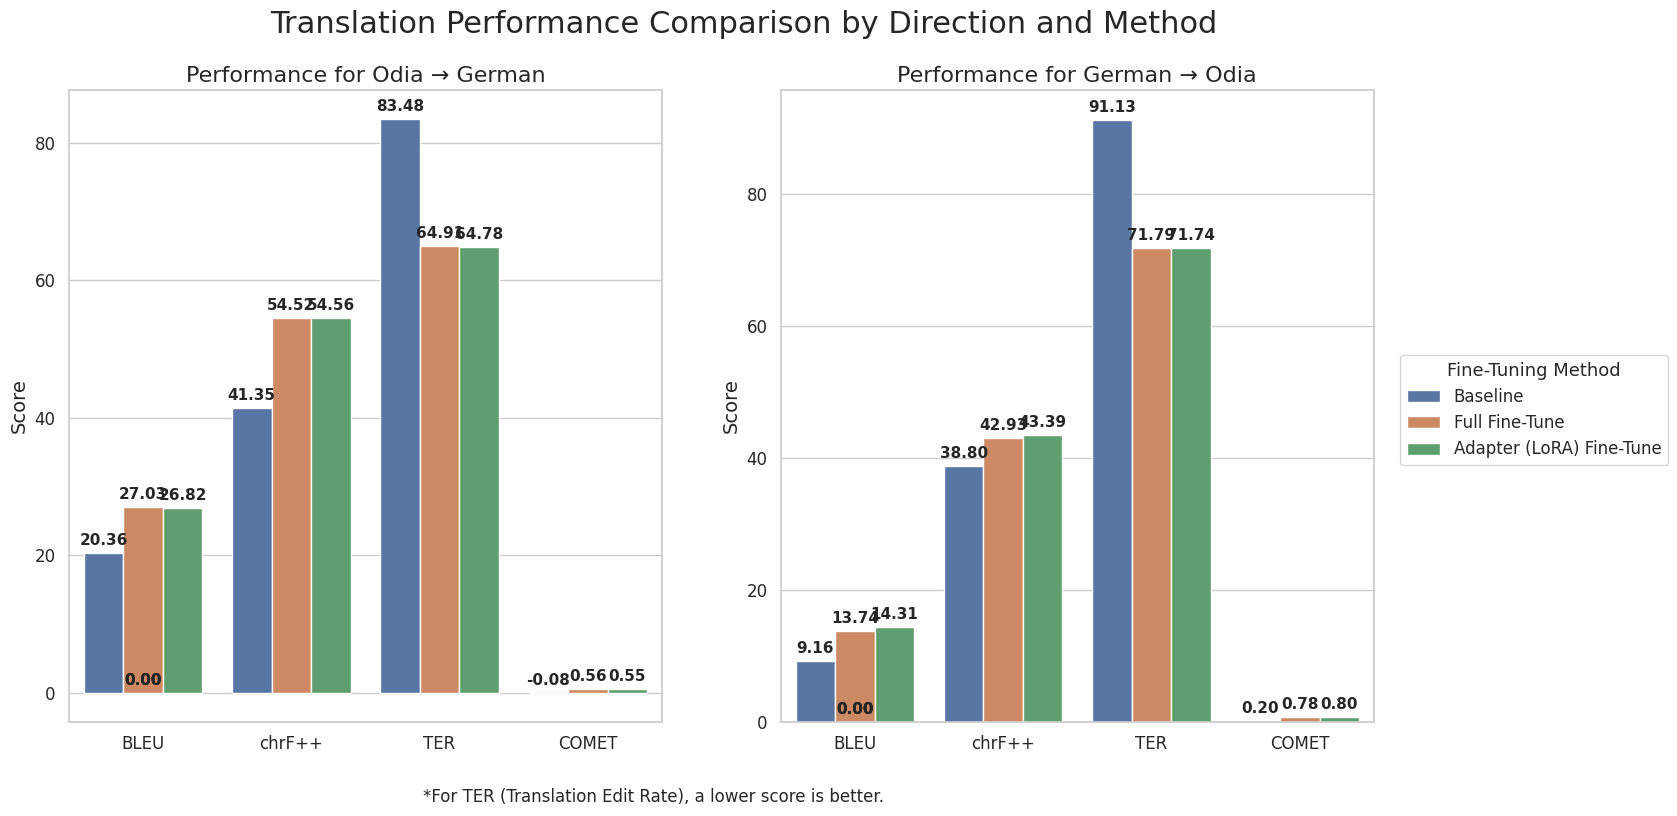

In [ ]:
# --- Generate Final Comparison Visualization ---
print("\n--- Generating Final Performance Visualization ---")

# --- CONSOLIDATE RESULTS DATA ---
plot_data = [
    # Odia -> German Data
    {'Metric': 'BLEU', 'Direction': 'Odia → German', 'Model': 'Baseline', 'Score': baseline_ori_deu_metrics['bleu']},
    {'Metric': 'chrF++', 'Direction': 'Odia → German', 'Model': 'Baseline', 'Score': baseline_ori_deu_metrics['chrf']},
    {'Metric': 'TER', 'Direction': 'Odia → German', 'Model': 'Baseline', 'Score': baseline_ori_deu_metrics['ter']},
    {'Metric': 'COMET', 'Direction': 'Odia → German', 'Model': 'Baseline', 'Score': baseline_ori_deu_metrics['comet']},

    {'Metric': 'BLEU', 'Direction': 'Odia → German', 'Model': 'Full Fine-Tune', 'Score': full_finetune_ori_deu_metrics['bleu']},
    {'Metric': 'chrF++', 'Direction': 'Odia → German', 'Model': 'Full Fine-Tune', 'Score': full_finetune_ori_deu_metrics['chrf']},
    {'Metric': 'TER', 'Direction': 'Odia → German', 'Model': 'Full Fine-Tune', 'Score': full_finetune_ori_deu_metrics['ter']},
    {'Metric': 'COMET', 'Direction': 'Odia → German', 'Model': 'Full Fine-Tune', 'Score': full_finetune_ori_deu_metrics['comet']},

    {'Metric': 'BLEU', 'Direction': 'Odia → German', 'Model': 'Adapter (LoRA) Fine-Tune', 'Score': adapter_ori_deu_metrics['bleu']},
    {'Metric': 'chrF++', 'Direction': 'Odia → German', 'Model': 'Adapter (LoRA) Fine-Tune', 'Score': adapter_ori_deu_metrics['chrf']},
    {'Metric': 'TER', 'Direction': 'Odia → German', 'Model': 'Adapter (LoRA) Fine-Tune', 'Score': adapter_ori_deu_metrics['ter']},
    {'Metric': 'COMET', 'Direction': 'Odia → German', 'Model': 'Adapter (LoRA) Fine-Tune', 'Score': adapter_ori_deu_metrics['comet']},

    # German -> Odia Data
    {'Metric': 'BLEU', 'Direction': 'German → Odia', 'Model': 'Baseline', 'Score': baseline_deu_ori_metrics['bleu']},
    {'Metric': 'chrF++', 'Direction': 'German → Odia', 'Model': 'Baseline', 'Score': baseline_deu_ori_metrics['chrf']},
    {'Metric': 'TER', 'Direction': 'German → Odia', 'Model': 'Baseline', 'Score': baseline_deu_ori_metrics['ter']},
    {'Metric': 'COMET', 'Direction': 'German → Odia', 'Model': 'Baseline', 'Score': baseline_deu_ori_metrics['comet']},

    {'Metric': 'BLEU', 'Direction': 'German → Odia', 'Model': 'Full Fine-Tune', 'Score': full_finetune_deu_ori_metrics['bleu']},
    {'Metric': 'chrF++', 'Direction': 'German → Odia', 'Model': 'Full Fine-Tune', 'Score': full_finetune_deu_ori_metrics['chrf']},
    {'Metric': 'TER', 'Direction': 'German → Odia', 'Model': 'Full Fine-Tune', 'Score': full_finetune_deu_ori_metrics['ter']},
    {'Metric': 'COMET', 'Direction': 'German → Odia', 'Model': 'Full Fine-Tune', 'Score': full_finetune_deu_ori_metrics['comet']},

    {'Metric': 'BLEU', 'Direction': 'German → Odia', 'Model': 'Adapter (LoRA) Fine-Tune', 'Score': adapter_deu_ori_metrics['bleu']},
    {'Metric': 'chrF++', 'Direction': 'German → Odia', 'Model': 'Adapter (LoRA) Fine-Tune', 'Score': adapter_deu_ori_metrics['chrf']},
    {'Metric': 'TER', 'Direction': 'German → Odia', 'Model': 'Adapter (LoRA) Fine-Tune', 'Score': adapter_deu_ori_metrics['ter']},
    {'Metric': 'COMET', 'Direction': 'German → Odia', 'Model': 'Adapter (LoRA) Fine-Tune', 'Score': adapter_deu_ori_metrics['comet']},
]

# The model name in the results dictionary is 'Fine-Tuned', but for the legend let's rename it
for item in plot_data:
  if item['Model'] == 'Fine-Tuned':
    item['Model'] = 'Full Fine-Tune'

final_plot_df = pd.DataFrame(plot_data)


# --- CREATE THE VISUALIZATION ---

# Set the theme
sns.set_theme(style="whitegrid")

# This ensures "Baseline" is always the same color, "Full Fine-Tune" is always another, etc.
palette_dict = {
    "Baseline": "C0",
    "Full Fine-Tune": "C1",
    "Adapter (LoRA) Fine-Tune": "C2"
}

# Create a figure and a set of subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Define the two directions for the loop
directions = ['Odia → German', 'German → Odia']

# Loop through the two axes and directions to create the plots
for i, direction in enumerate(directions):
  ax = axes[i]
  subset_data = final_plot_df[final_plot_df['Direction'] == direction]

  # Create the bar plot on the specific axis, using the consistent palette
  sns.barplot(
      data=subset_data,
      x='Metric',
      y='Score',
      hue='Model',
      palette=palette_dict,
      ax=ax
  )

  ax.set_title(f'Performance for {direction}', fontsize=16)
  ax.set_xlabel('')
  ax.set_ylabel('Score', fontsize=14)
  ax.tick_params(axis='x', labelsize=12)
  ax.tick_params(axis='y', labelsize=12)

  # Add value annotations on top of the bars
  for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}',
     (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9), textcoords='offset points',
                fontsize=11, fontweight='bold')

# --- FINALIZE THE PLOT ---

# Add a single main title for the entire figure
fig.suptitle('Translation Performance Comparison by Direction and Method', fontsize=22, y=1.0)

# Get handles and labels from one of the plots
handles, labels = axes[0].get_legend_handles_labels()

# Remove the automatically generated legends from the subplots
axes[0].get_legend().remove()
axes[1].get_legend().remove()

# Adjust the subplot layout to make space on the right for the legend
fig.subplots_adjust(right=0.85, top=0.90)

# Create a single, clean legend for the entire figure in the new empty space
fig.legend(
    handles,
    labels,
    loc='center left',
    title='Fine-Tuning Method',
    fontsize=12,
    title_fontsize=13,
    bbox_to_anchor=(0.86, 0.5)
)

# Add a note about TER at the bottom
fig.text(0.45, 0.01, '*For TER (Translation Edit Rate), a lower score is better.', ha='center', fontsize=12)

plt.show()


--- Generating LoRA vs. Baseline Improvement Chart ---


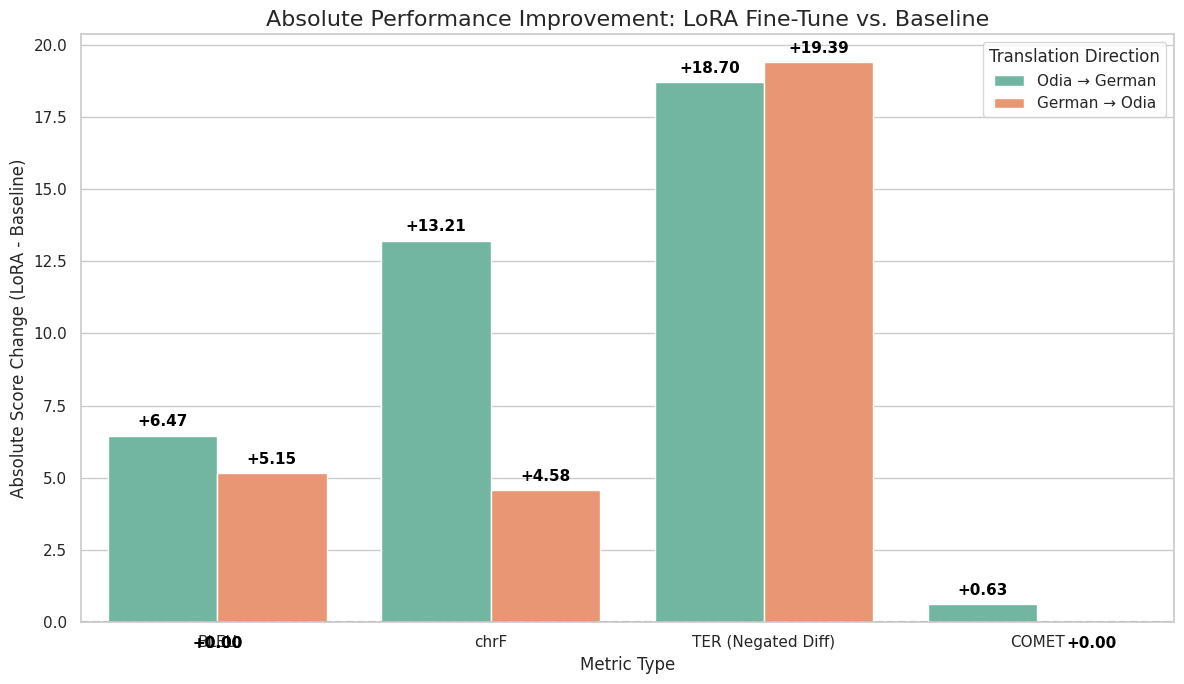


✅ LoRA vs. Baseline Improvement Chart generated.


In [ ]:
# --- CREATE SECONDARY VISUALIZATION (LoRA vs. Baseline Improvement Bar Chart) ---

print("\n--- Generating LoRA vs. Baseline Improvement Chart ---")

# --- Step A: Consolidate Metrics into DataFrames for Calculation ---
# We use the existing results data structures (or DataFrame) to calculate the difference.
# We will create two temporary DataFrames for Odia->German and German->Odia.

# Odia -> German Improvement Data
improve_od_data = {
    'Metric': ['BLEU', 'chrF', 'TER', 'COMET'],
    'Baseline': [baseline_ori_deu_metrics['bleu'], baseline_ori_deu_metrics['chrf'], baseline_ori_deu_metrics['ter'], baseline_ori_deu_metrics['comet']],
    'LoRA': [adapter_ori_deu_metrics['bleu'], adapter_ori_deu_metrics['chrf'], adapter_ori_deu_metrics['ter'], adapter_ori_deu_metrics['comet']],
}
df_improve_od = pd.DataFrame(improve_od_data).set_index('Metric')

# German -> Odia Improvement Data
improve_do_data = {
    'Metric': ['BLEU', 'chrF', 'TER', 'COMET'],
    'Baseline': [baseline_deu_ori_metrics['bleu'], baseline_deu_ori_metrics['chrf'], baseline_deu_ori_metrics['ter'], adapter_deu_ori_metrics['comet']],
    'LoRA': [adapter_deu_ori_metrics['bleu'], adapter_deu_ori_metrics['chrf'], adapter_deu_ori_metrics['ter'], adapter_deu_ori_metrics['comet']],
}
df_improve_do = pd.DataFrame(improve_do_data).set_index('Metric')

# --- Step B: Calculate the Difference (LoRA - Baseline) ---
improve_od = (df_improve_od['LoRA'] - df_improve_od['Baseline']).to_frame('Difference')
improve_do = (df_improve_do['LoRA'] - df_improve_do['Baseline']).to_frame('Difference')

# --- Step C: Adjust TER for visual interpretation ---
# For TER (lower is better), we want a lower score to result in a positive bar height (Improvement).
# Since Difference = LoRA - Baseline, a negative number indicates improvement. We negate it.
improve_od.loc['TER', 'Difference'] *= -1
improve_do.loc['TER', 'Difference'] *= -1

# --- Step D: Combine and Plot ---
improve_od['Direction'] = 'Odia → German'
improve_do['Direction'] = 'German → Odia'
df_improve = pd.concat([improve_od.reset_index(), improve_do.reset_index()])

# Adjust TER label for display clarity
df_improve.loc[df_improve['Metric'] == 'TER', 'Metric'] = 'TER (Negated Diff)'

# Create the improvement bar plot
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(12, 7))

sns.barplot(
    data=df_improve,
    x='Metric',
    y='Difference',
    hue='Direction',
    palette='Set2',
    ax=ax
)

# Add annotations
for p in ax.patches:
    value = p.get_height()

    # Format text to include + or - sign
    text = f'{value:+.2f}'

    ax.annotate(text,
                (p.get_x() + p.get_width() / 2., value),
                ha='center', va='center',
                xytext=(0, 10 if value > 0 else -15), # Adjust position based on bar direction
                textcoords='offset points',
                fontsize=11, fontweight='bold',
                color='black')

# Draw a zero line for reference
ax.axhline(0, color='gray', linestyle='--')

# Final formatting
ax.set_title('Absolute Performance Improvement: LoRA Fine-Tune vs. Baseline', fontsize=16)
ax.set_xlabel('Metric Type', fontsize=12)
ax.set_ylabel('Absolute Score Change (LoRA - Baseline)', fontsize=12)

ax.legend(title='Translation Direction', loc='upper right')

plt.tight_layout()
plt.show()

print("\n✅ LoRA vs. Baseline Improvement Chart generated.")


--- Generating LoRA vs. Full Fine-Tune Difference Chart ---


/tmp/ipython-input-495267355.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


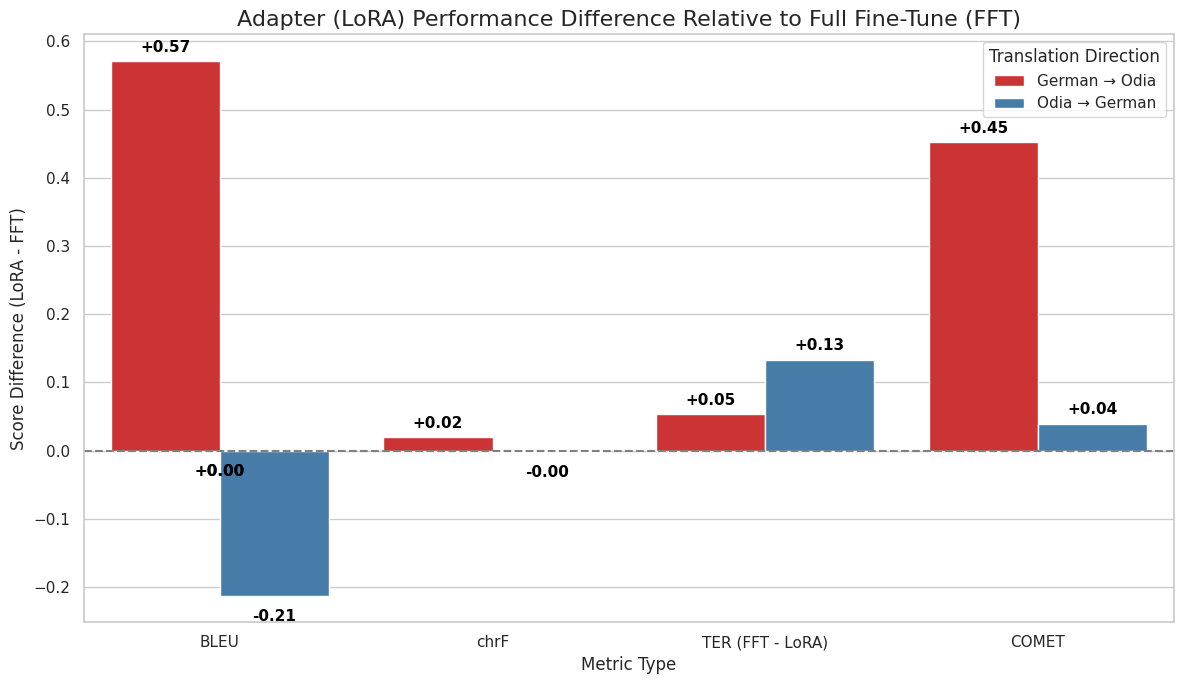


✅ LoRA vs. FFT Difference Chart generated.


In [ ]:
# --- CREATE SECONDARY VISUALIZATION (LoRA vs. FFT Difference Bar Chart) ---

print("\n--- Generating LoRA vs. Full Fine-Tune Difference Chart ---")

# --- Step A: Calculate the Difference (LoRA Score - FFT Score) ---

# Reformat the data: Pivot by Direction and Model, stack Metrics
df_diff_prep = final_plot_df.pivot_table(
    index=['Direction', 'Metric'],
    columns='Model',
    values='Score'
).reset_index()

# Calculate the difference: LoRA - FFT
df_diff_prep['Difference'] = df_diff_prep['Adapter (LoRA) Fine-Tune'] - df_diff_prep['Full Fine-Tune']

# --- Step B: Adjust TER for visual interpretation ---
# Improvement for TER is defined as: FFT_Score - LoRA_Score (We want higher bars to mean better performance)
# Since Difference = LoRA - FFT, we multiply TER by -1.
df_diff_prep.loc[df_diff_prep['Metric'].str.contains('TER'), 'Difference'] *= -1

# Create the plot
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(12, 7))

# Plot the difference
sns.barplot(
    data=df_diff_prep,
    x='Metric',
    y='Difference',
    hue='Direction',
    palette='Set1',
    ax=ax
)

# Add annotations
for p in ax.patches:
    value = p.get_height()

    # Format text to include + or - sign
    text = f'{value:+.2f}'

    ax.annotate(text,
                (p.get_x() + p.get_width() / 2., value),
                ha='center', va='center',
                xytext=(0, 10 if value > 0 else -15), # Adjust position based on bar direction
                textcoords='offset points',
                fontsize=11, fontweight='bold',
                color='black')

# Draw a zero line for reference
ax.axhline(0, color='gray', linestyle='--')

# Final formatting
ax.set_title('Adapter (LoRA) Performance Difference Relative to Full Fine-Tune (FFT)', fontsize=16)
ax.set_xlabel('Metric Type', fontsize=12)
ax.set_ylabel('Score Difference (LoRA - FFT)', fontsize=12)

# Set the TER label to reflect the adjustment
ax.set_xticklabels(
    ['BLEU', 'chrF', 'TER (FFT - LoRA)', 'COMET']
)

ax.legend(title='Translation Direction', loc='upper right')

plt.tight_layout()
plt.show()

print("\n✅ LoRA vs. FFT Difference Chart generated.")

--- Generating Training and Validation Curves ---


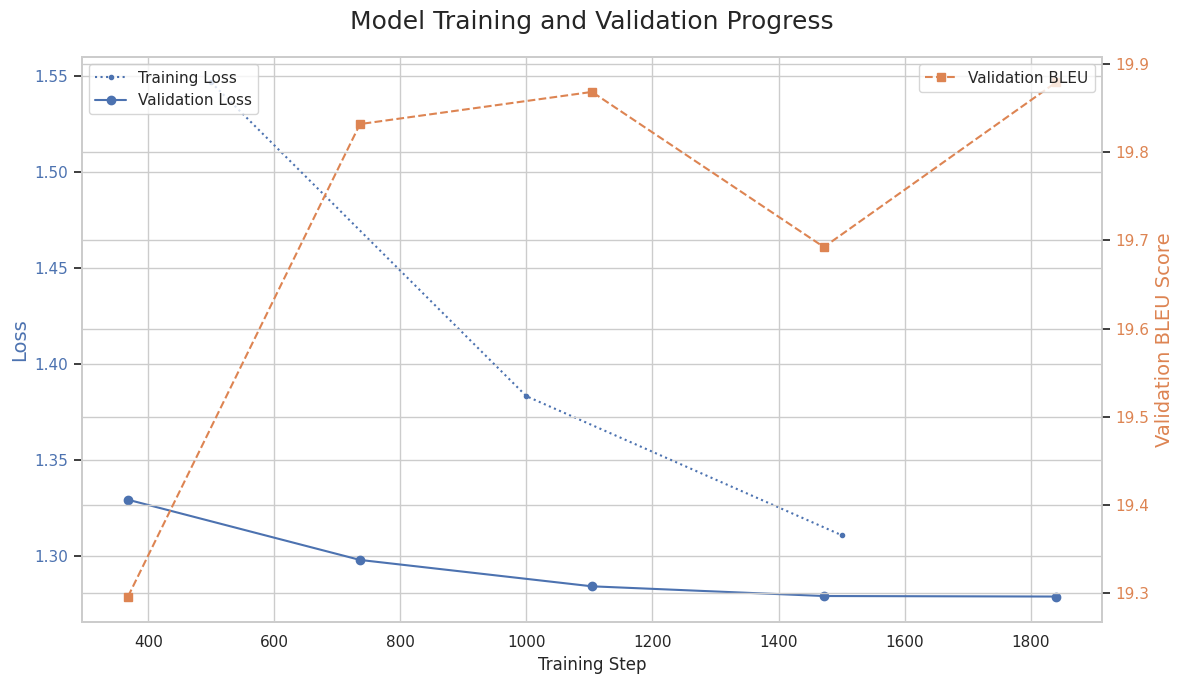

In [ ]:
# --- VISUALIZATION: Training and Validation Progress ---

print("--- Generating Training and Validation Curves ---")

# The trainer object holds the history of the training run
# Extract the logs to a pandas DataFrame for easy plotting
try:
  log_history = trainer.state.log_history
  df_logs = pd.DataFrame(log_history)

  # Separate training and evaluation logs
  df_train = df_logs[df_logs['loss'].notna()].copy()
  df_eval = df_logs[df_logs['eval_loss'].notna()].copy()

  # Create the plot with two y-axes
  sns.set_theme(style="whitegrid")
  fig, ax1 = plt.subplots(figsize=(12, 7))

  # Plot Training and Validation Loss on the primary y-axis (ax1)
  ax1.set_xlabel('Training Step', fontsize=12)
  ax1.set_ylabel('Loss', color='C0', fontsize=14)
  ax1.plot(df_train['step'], df_train['loss'], color='C0', marker='.', linestyle=':', label='Training Loss')
  ax1.plot(df_eval['step'], df_eval['eval_loss'], color='C0', marker='o', linestyle='-', label='Validation Loss')
  ax1.tick_params(axis='y', labelcolor='C0')
  ax1.legend(loc='upper left')

  # Create a second y-axis for the BLEU score
  ax2 = ax1.twinx()
  ax2.set_ylabel('Validation BLEU Score', color='C1', fontsize=14)
  ax2.plot(df_eval['step'], df_eval['eval_bleu'], color='C1', marker='s', linestyle='--', label='Validation BLEU')
  ax2.tick_params(axis='y', labelcolor='C1')
  ax2.legend(loc='upper right')

  plt.title('Model Training and Validation Progress', fontsize=18, pad=20)
  fig.tight_layout()
  plt.show()

except NameError:
  print("\n⛔️ ERROR: The 'trainer' object was not found.")
  print("Please ensure you have run the main Fine-Tuning cell successfully before running this visualization cell.")
except Exception as e:
  print(f"\nAn error occurred: {e}")